In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from evaluation.portfolio import portfolio_roi, portfolio_kelly, portfolio_breakdown

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')
ts = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season.parquet')
final = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season_final.parquet')
thr = json.load(open('C:/Users/twluc/frame/01_data/02_features/thresholds.json'))

In [2]:
final = (
    final
    .sort_values(['league', 'season', 'season_points_avg', 'season_goals_diff_avg'],
                 ascending=[True, True, False, False])
    .assign(standing=lambda df: df.groupby(['league', 'season']).cumcount() + 1)
)

In [3]:
def plot_totaldiff_scatter(df, group):
    
    fig, ax = plt.subplots(figsize=(9, 7))
    for grp_val, grp in df.groupby(group):
        ax.scatter(grp['season_goals_total_avg'], grp['season_goals_diff_avg'], label=grp_val, alpha=0.6, s=20)

    ax.axvline(thr['goals_total_p33'], color='gray', linewidth=0.6, linestyle='--')
    ax.axvline(thr['goals_total_p67'], color='gray', linewidth=0.6, linestyle='--')
    ax.axhline(thr['goals_diff_p33'],  color='gray', linewidth=0.6, linestyle='--')
    ax.axhline(thr['goals_diff_p67'],  color='gray', linewidth=0.6, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8)

    ax.set_xlim(1.5, 4.5) 
    ax.set_ylim(-2.5,2.5)

    ax.set_xlabel('goals total avg'); ax.set_ylabel('goals diff avg')
    ax.legend(markerscale=2, fontsize=8)
    plt.tight_layout(); plt.show()


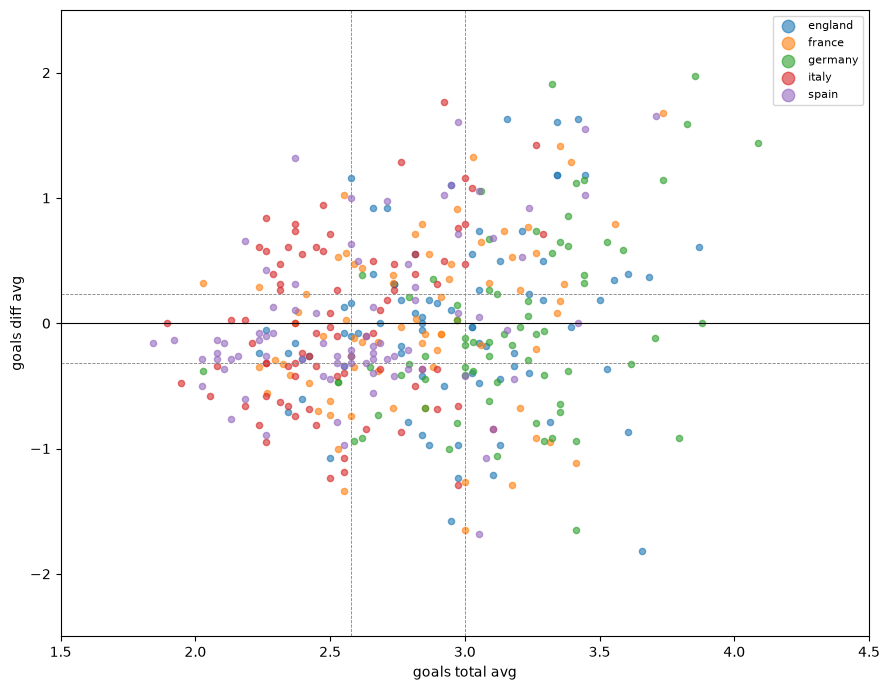

In [4]:
plot_totaldiff_scatter(final,'league')

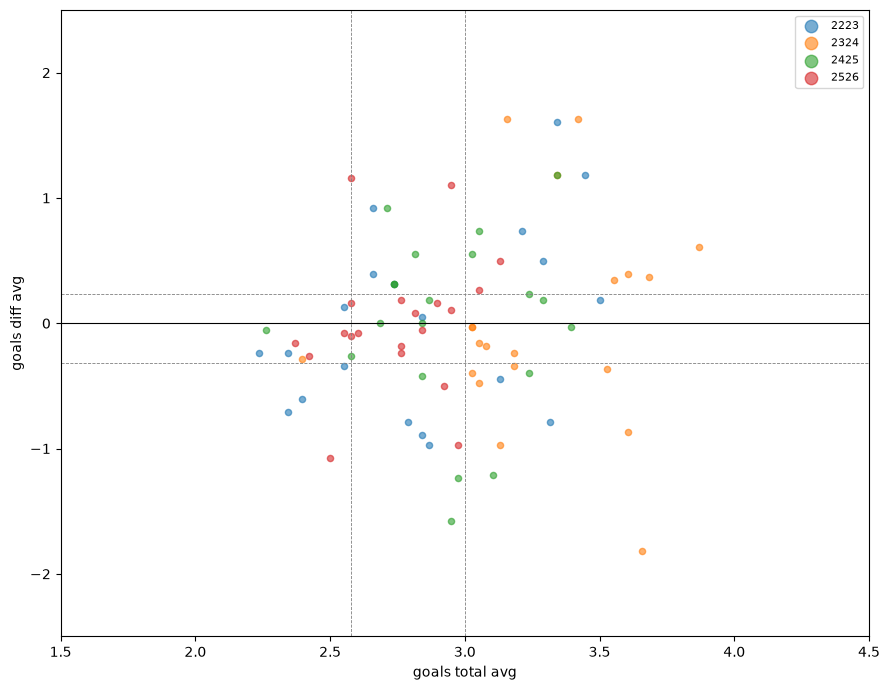

In [5]:
england = final[final['league']=='england']
plot_totaldiff_scatter(england,'season')

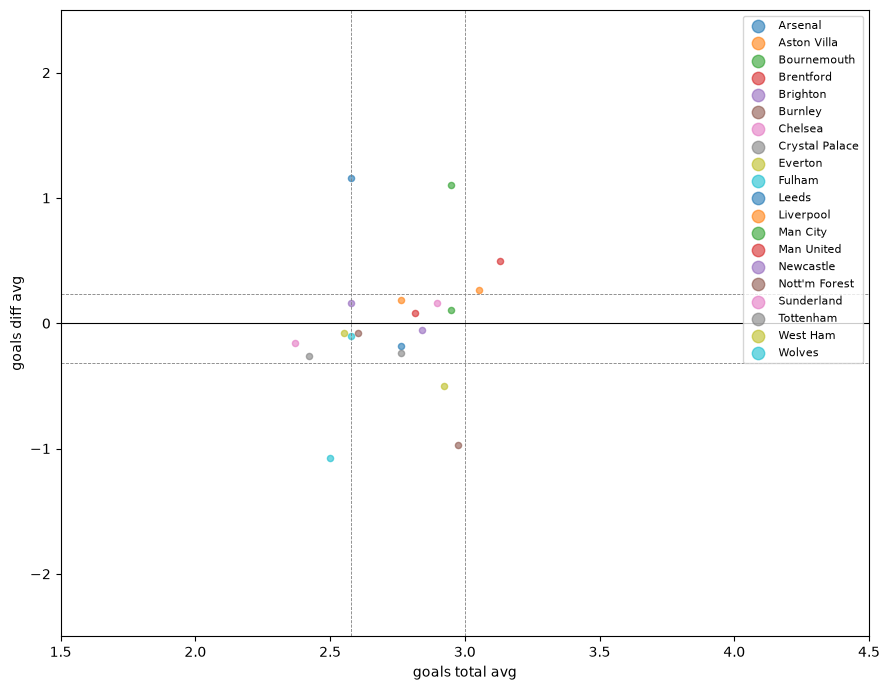

In [6]:
england2526 = final.query("league == 'england' and season == '2526'")
plot_totaldiff_scatter(england2526,'team')

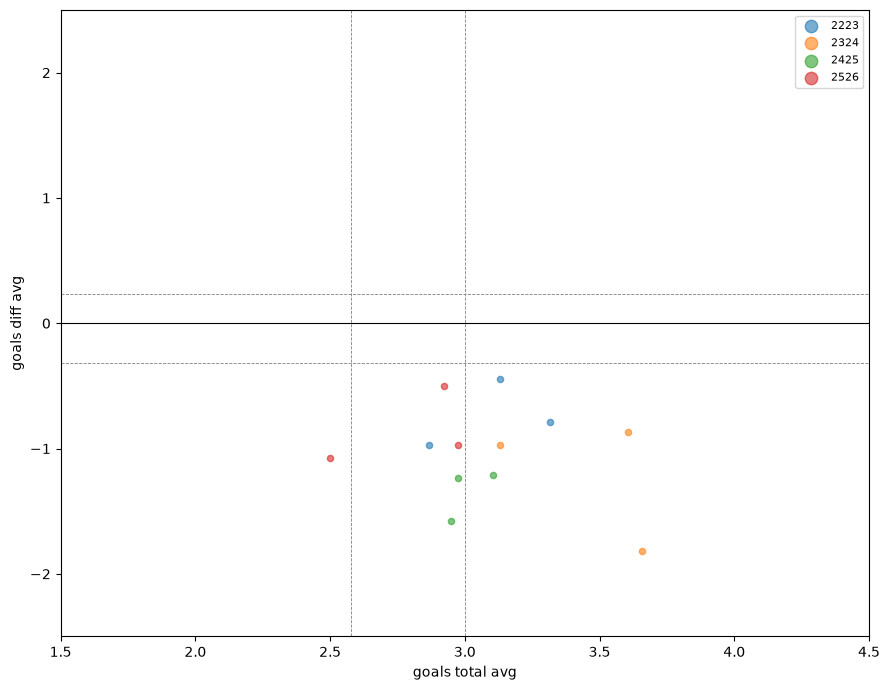

In [7]:
query = "league == 'england' and standing >= 18"
plot_totaldiff_scatter(final.query(query),'season')

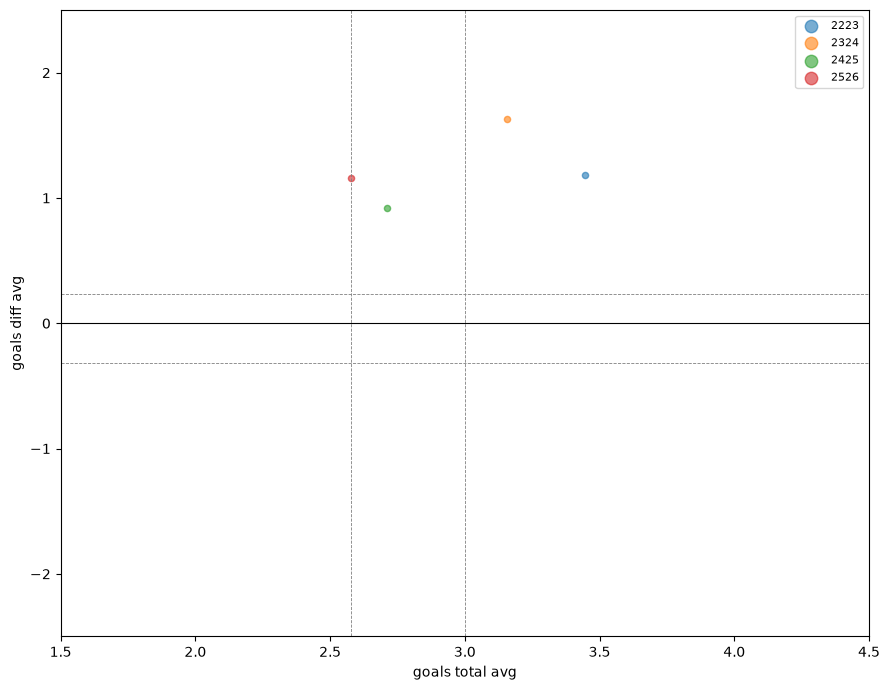

In [8]:
query = "team == 'Arsenal'"
plot_totaldiff_scatter(final.query(query),'season')

In [9]:
final.groupby(['league', 'season_goals_total_cat3q']).size().unstack()[['low','medium','high']]

season_goals_total_cat3q,low,medium,high
league,,,
england,16,28,36
france,23,29,22
germany,3,20,49
italy,50,26,4
spain,40,26,14


In [10]:
final.groupby(['league', 'season_goals_diff_cat3q']).size().unstack()[['low','medium','high']]

season_goals_diff_cat3q,low,medium,high
league,,,
england,23,31,26
france,23,23,28
germany,30,20,22
italy,30,18,32
spain,20,39,21


In [11]:
sub = abt[abt['homet_game_number'] > 8]
cols = ['homet_season_goals_total_cat2m', 'homet_season_goals_diff_cat2m',
        'awayt_season_goals_total_cat2m', 'awayt_season_goals_diff_cat2m']

groups = {k: g for k, g in sub.groupby(cols)}
results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
    pval = binomtest(r['wins'], r['n_bets'], groups[k]['mrkt_draw_impl'].mean()).pvalue
    print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")


('high', 'positive', 'high', 'negative') roi=0.230  n=384  p=0.032
('high', 'negative', 'low', 'negative') roi=0.090  n=332  p=0.303
('low', 'negative', 'low', 'negative') roi=0.037  n=706  p=0.513
('high', 'negative', 'high', 'negative') roi=0.055  n=384  p=0.527
('low', 'positive', 'low', 'negative') roi=0.052  n=382  p=0.552
('high', 'negative', 'high', 'positive') roi=0.035  n=412  p=0.687
('low', 'positive', 'high', 'negative') roi=0.019  n=174  p=0.858
('high', 'positive', 'low', 'positive') roi=-0.001  n=226  p=1.000
('high', 'negative', 'low', 'positive') roi=-0.165  n=166  p=0.223
('high', 'positive', 'low', 'negative') roi=-0.089  n=408  p=0.392
('low', 'positive', 'low', 'positive') roi=-0.170  n=234  p=0.112
('low', 'negative', 'high', 'positive') roi=-0.122  n=399  p=0.169
('low', 'negative', 'low', 'positive') roi=-0.109  n=414  p=0.159
('low', 'positive', 'high', 'positive') roi=-0.241  n=220  p=0.033
('high', 'positive', 'high', 'positive') roi=-0.212  n=360  p=0.023
('

In [12]:
sub = abt[abt['homet_game_number'] > 8]
cols = ['homet_season_goals_total_cat3q', 'homet_season_goals_diff_cat3q',
        'awayt_season_goals_total_cat3q', 'awayt_season_goals_diff_cat3q']

groups = {k: g for k, g in sub.groupby(cols)}
results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
    pval = binomtest(r['wins'], r['n_bets'], groups[k]['mrkt_draw_impl'].mean()).pvalue
    print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")


('medium', 'high', 'medium', 'low') roi=0.749  n=71  p=0.002
('low', 'low', 'low', 'low') roi=0.281  n=120  p=0.048
('high', 'medium', 'high', 'low') roi=0.608  n=65  p=0.009
('medium', 'low', 'low', 'low') roi=0.298  n=104  p=0.053
('high', 'low', 'high', 'medium') roi=0.413  n=78  p=0.039
('high', 'high', 'high', 'low') roi=0.351  n=120  p=0.087
('low', 'medium', 'low', 'low') roi=0.175  n=106  p=0.284
('high', 'low', 'low', 'medium') roi=0.404  n=44  p=0.097
('high', 'medium', 'low', 'low') roi=0.556  n=32  p=0.070
('medium', 'low', 'high', 'medium') roi=0.326  n=48  p=0.198
('low', 'medium', 'medium', 'high') roi=0.148  n=88  p=0.405
('medium', 'high', 'high', 'low') roi=0.286  n=63  p=0.268
('high', 'high', 'low', 'high') roi=0.168  n=57  p=0.450
('high', 'high', 'medium', 'medium') roi=0.147  n=77  p=0.482
('medium', 'low', 'medium', 'medium') roi=0.126  n=60  p=0.572
('medium', 'low', 'high', 'high') roi=0.074  n=120  p=0.669
('low', 'high', 'medium', 'low') roi=0.155  n=56  p=0

In [25]:
def keep(k, max_medium=2):
    return 'low' not in k and k.count('medium') <= max_medium

filtered = pd.concat([g for k, g in groups.items() if keep(k)])
for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
    if not keep(k): continue
    pval = binomtest(r['wins'], r['n_bets'], groups[k]['mrkt_draw_impl'].mean()).pvalue
    print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")
r = portfolio_roi(filtered['mrkt_home_impl'], filtered['t_home_flg'])
pval = binomtest(r['wins'], r['n_bets'], filtered['mrkt_home_impl'].mean()).pvalue
print(r, f"p={pval:.3f}")


('high', 'high', 'medium', 'medium') roi=0.147  n=77  p=0.482
('high', 'medium', 'high', 'high') roi=0.031  n=92  p=0.903
('medium', 'high', 'high', 'medium') roi=-0.114  n=33  p=0.840
('high', 'medium', 'high', 'medium') roi=-0.140  n=31  p=0.838
('high', 'high', 'medium', 'high') roi=-0.078  n=76  p=0.790
('high', 'medium', 'medium', 'high') roi=-0.157  n=44  p=0.613
('medium', 'medium', 'high', 'high') roi=-0.181  n=81  p=0.375
('high', 'high', 'high', 'medium') roi=-0.320  n=87  p=0.144
('medium', 'high', 'high', 'high') roi=-0.347  n=77  p=0.089
('medium', 'high', 'medium', 'high') roi=-0.513  n=61  p=0.014
('high', 'high', 'high', 'high') roi=-0.316  n=158  p=0.025
{'n_bets': 817, 'capital': 385.028, 'wins': 409, 'profit': 23.972, 'roi': 0.0623} p=0.099


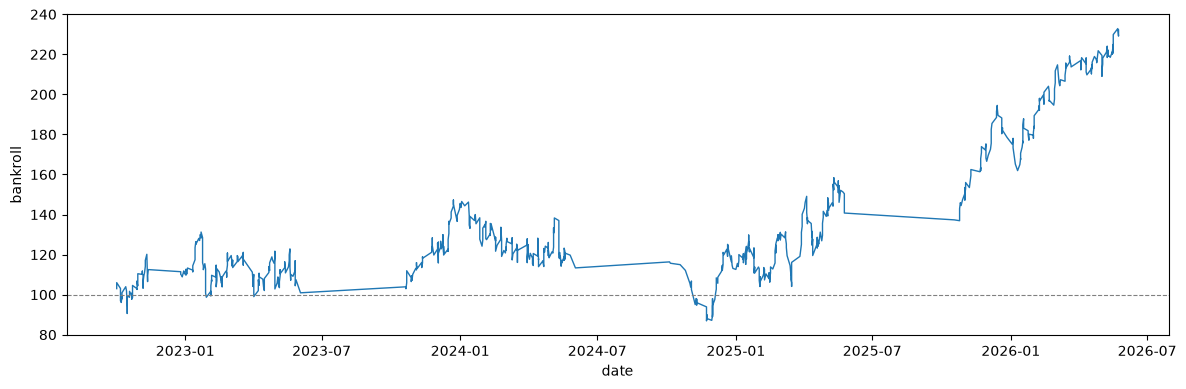

{'n_bets': 817,
 'capital': 2956.5603,
 'wins': 409,
 'profit': 132.1053,
 'roi': 0.0447,
 'bankroll_roi': 1.3211}

In [28]:
portfolio_kelly(filtered['mrkt_home_impl'], filtered['t_home_flg'], plot=True, dates=filtered['date'], model_probs=filtered['mrkt_home_impl'] * 1.06)

In [29]:
from sklearn.cluster import KMeans

In [35]:
def cluster_roi(n_clusters, outcome='draw'):
    impl_col = f'mrkt_{outcome}_impl'
    flg_col  = f't_{outcome}_flg'

    km = KMeans(n_clusters=n_clusters, random_state=0)
    final[f'kmeans_cluster{n_clusters}'] = km.fit_predict(final[['season_goals_total_avg', 'season_goals_diff_avg']]).astype(str)
    plot_totaldiff_scatter(final, f'kmeans_cluster{n_clusters}')

    sub = abt[abt['homet_game_number'] > 8].copy()
    sub['homet_km'] = km.predict(sub[['homet_season_goals_total_avg', 'homet_season_goals_diff_avg']].rename(columns=lambda c: c.replace('homet_', ''))).astype(str)
    sub['awayt_km'] = km.predict(sub[['awayt_season_goals_total_avg', 'awayt_season_goals_diff_avg']].rename(columns=lambda c: c.replace('awayt_', ''))).astype(str)

    groups = {k: g for k, g in sub.groupby(['homet_km', 'awayt_km'])}
    results = {k: portfolio_roi(g[impl_col], g[flg_col]) for k, g in groups.items()}
    for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
        g = groups[k]
        pval = binomtest(r['wins'], r['n_bets'], g[impl_col].mean()).pvalue
        print(k, r, f"p={pval:.3f}")


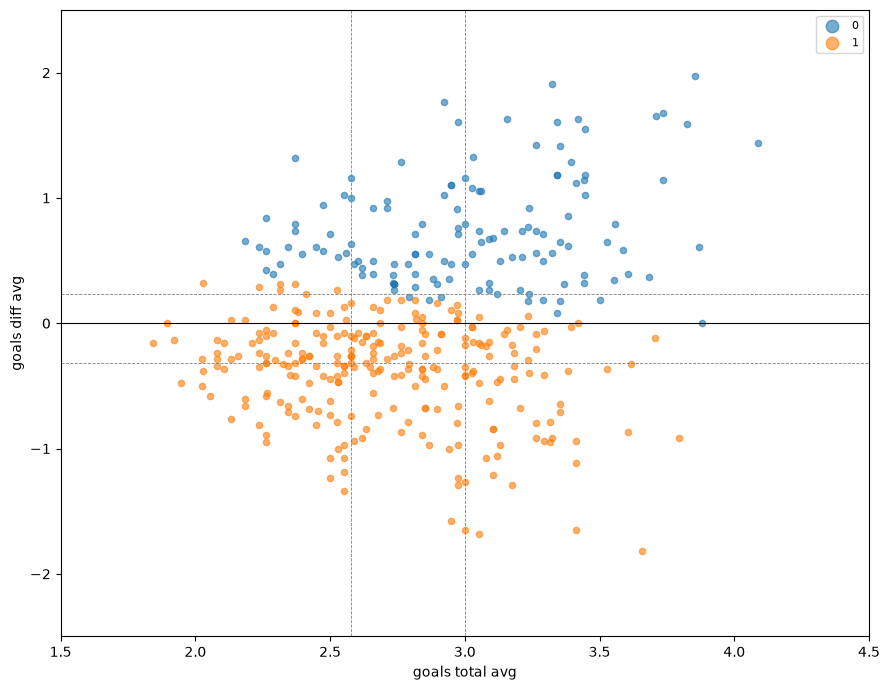

('0', '1') {'n_bets': 1286, 'capital': 273.411, 'wins': 279, 'profit': 5.589, 'roi': 0.0204} p=0.708
('1', '1') {'n_bets': 2251, 'capital': 647.082, 'wins': 633, 'profit': -14.082, 'roi': -0.0218} p=0.530
('1', '0') {'n_bets': 1297, 'capital': 337.235, 'wins': 322, 'profit': -15.235, 'roi': -0.0452} p=0.342
('0', '0') {'n_bets': 703, 'capital': 181.853, 'wins': 149, 'profit': -32.853, 'roi': -0.1807} p=0.004


In [36]:
cluster_roi(2)

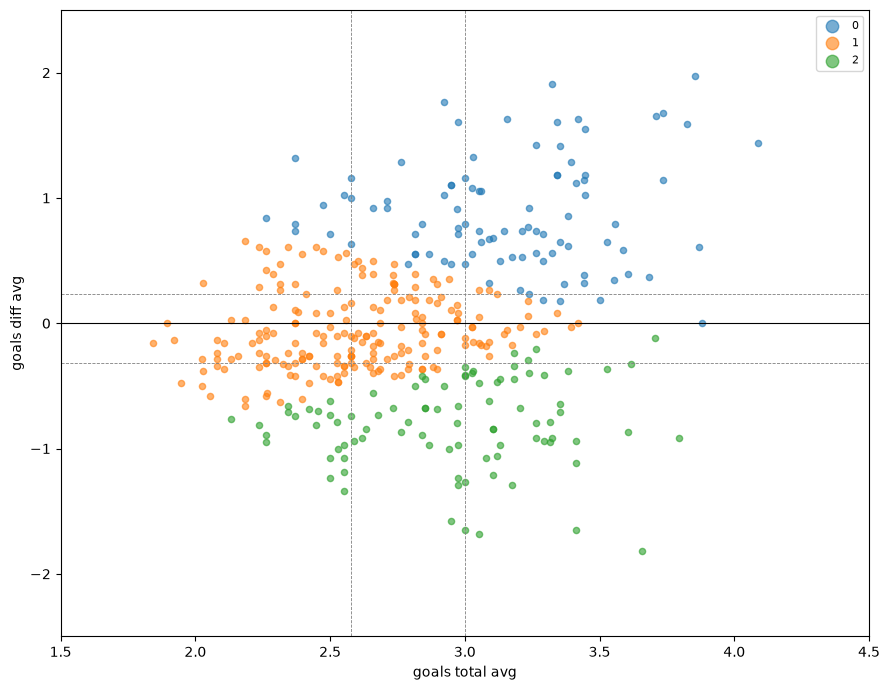

('0', '0') {'n_bets': 398, 'capital': 186.282, 'wins': 208, 'profit': 21.718, 'roi': 0.1166} p=0.031
('1', '0') {'n_bets': 659, 'capital': 191.44, 'wins': 188, 'profit': -3.44, 'roi': -0.018} p=0.797
('0', '1') {'n_bets': 630, 'capital': 410.983, 'wins': 399, 'profit': -11.983, 'roi': -0.0292} p=0.316
('2', '0') {'n_bets': 439, 'capital': 95.262, 'wins': 83, 'profit': -12.262, 'roi': -0.1287} p=0.165
('2', '2') {'n_bets': 456, 'capital': 209.49, 'wins': 191, 'profit': -18.49, 'roi': -0.0883} p=0.091
('0', '2') {'n_bets': 422, 'capital': 315.669, 'wins': 296, 'profit': -19.669, 'roi': -0.0623} p=0.029
('1', '2') {'n_bets': 669, 'capital': 375.898, 'wins': 355, 'profit': -20.898, 'roi': -0.0556} p=0.110
('1', '1') {'n_bets': 1202, 'capital': 548.865, 'wins': 524, 'profit': -24.865, 'roi': -0.0453} p=0.156
('2', '1') {'n_bets': 662, 'capital': 229.139, 'wins': 185, 'profit': -44.139, 'roi': -0.1926} p=0.000


In [39]:
cluster_roi(3,'home')

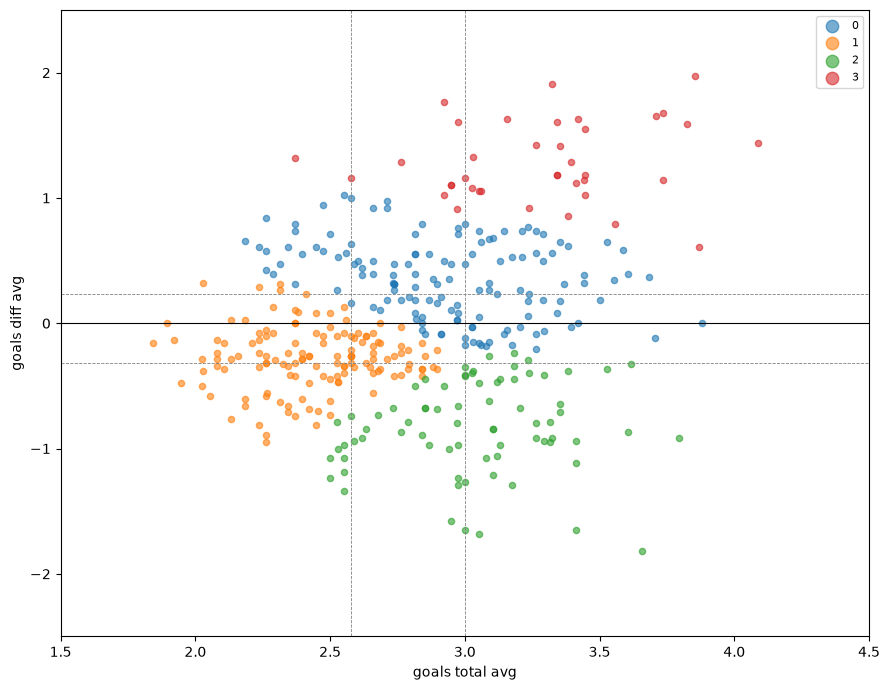

('0', '0') {'n_bets': 513, 'capital': 236.888, 'wins': 251, 'profit': 14.112, 'roi': 0.0596} p=0.215
('3', '3') {'n_bets': 81, 'capital': 38.512, 'wins': 42, 'profit': 3.488, 'roi': 0.0906} p=0.439
('3', '1') {'n_bets': 224, 'capital': 166.145, 'wins': 169, 'profit': 2.855, 'roi': 0.0172} p=0.703
('1', '2') {'n_bets': 359, 'capital': 191.807, 'wins': 193, 'profit': 1.193, 'roi': 0.0062} p=0.916
('0', '3') {'n_bets': 209, 'capital': 62.077, 'wins': 60, 'profit': -2.077, 'roi': -0.0335} p=0.820
('3', '2') {'n_bets': 159, 'capital': 128.669, 'wins': 126, 'profit': -2.669, 'roi': -0.0207} p=0.614
('2', '2') {'n_bets': 325, 'capital': 147.836, 'wins': 144, 'profit': -3.836, 'roi': -0.0259} p=0.697
('2', '3') {'n_bets': 167, 'capital': 29.112, 'wins': 25, 'profit': -4.112, 'roi': -0.1412} p=0.475
('3', '0') {'n_bets': 226, 'capital': 143.61, 'wins': 139, 'profit': -4.61, 'roi': -0.0321} p=0.534
('1', '3') {'n_bets': 225, 'capital': 48.008, 'wins': 42, 'profit': -6.008, 'roi': -0.1251} p=0.37

In [38]:
cluster_roi(4,'home')

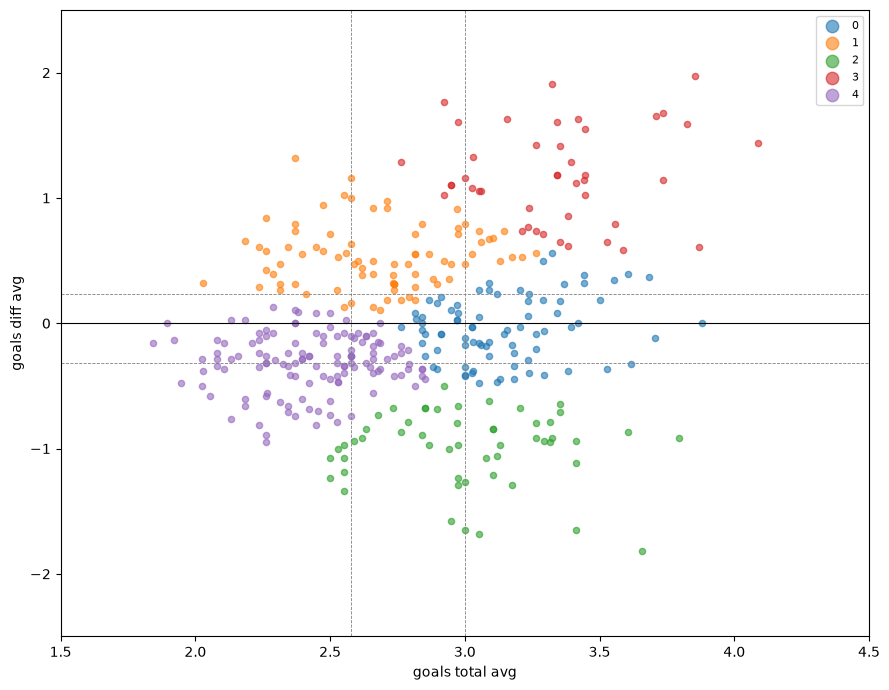

('1', '3') {'n_bets': 119, 'capital': 52.269, 'wins': 56, 'profit': 3.731, 'roi': 0.0714} p=0.518
('3', '1') {'n_bets': 143, 'capital': 31.064, 'wins': 34, 'profit': 2.936, 'roi': 0.0945} p=0.543
('0', '0') {'n_bets': 252, 'capital': 80.503, 'wins': 83, 'profit': 2.497, 'roi': 0.031} p=0.736
('4', '4') {'n_bets': 633, 'capital': 190.598, 'wins': 193, 'profit': 2.402, 'roi': 0.0126} p=0.829
('4', '3') {'n_bets': 211, 'capital': 124.695, 'wins': 127, 'profit': 2.305, 'roi': 0.0185} p=0.780
('2', '0') {'n_bets': 216, 'capital': 96.651, 'wins': 98, 'profit': 1.349, 'roi': 0.014} p=0.891
('3', '2') {'n_bets': 124, 'capital': 11.655, 'wins': 13, 'profit': 1.345, 'roi': 0.1154} p=0.644
('2', '3') {'n_bets': 117, 'capital': 78.714, 'wins': 80, 'profit': 1.286, 'roi': 0.0163} p=0.844
('3', '3') {'n_bets': 90, 'capital': 30.302, 'wins': 30, 'profit': -0.302, 'roi': -0.01} p=1.000
('0', '4') {'n_bets': 253, 'capital': 68.327, 'wins': 68, 'profit': -0.327, 'roi': -0.0048} p=1.000
('4', '2') {'n_be

In [42]:
cluster_roi(5,'away')